# 04. 탐색적 데이터 분석 (EDA)

**목표**: 반려견 질병 말뭉치의 분포와 패턴을 시각화하여 중간 인사이트 도출

| 분석 항목 | 내용 |
|----------|------|
| 생애주기별 질병 빈도 | 자견/성견/노령견별 주요 질병 분포 |
| 진료과별 분포 | 5개 진료과 데이터 현황 |
| 워드클라우드 | 생애주기별 핵심 키워드 시각화 |
| 텍스트 길이 분포 | Q&A 길이 통계 |
| 질병-진료과 교차 분석 | 히트맵 |

> **보고서 연계**: 4번(EDA), 5번(중간 인사이트) 항목 직결

## 0. 환경 설정

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud
from collections import Counter

from utils.config import DATA_PROCESSED

# 한글 폰트
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

PREPROCESSED_PATH = DATA_PROCESSED / 'corpus_preprocessed.csv'
EDA_OUTPUT        = DATA_PROCESSED / 'eda_figures'
EDA_OUTPUT.mkdir(exist_ok=True)

print("환경 설정 완료")

환경 설정 완료


## 1. 데이터 로드

In [2]:
df = pd.read_csv(PREPROCESSED_PATH)
print(f"전체 레코드: {len(df):,}개")
print(f"컬럼: {list(df.columns)}")
df.head(2)

전체 레코드: 21,604개
컬럼: ['lifeCycle', 'department', 'disease', 'input', 'output', 'split', 'input_clean', 'output_clean', 'input_normalized', 'input_tokens', 'output_tokens']


,lifeCycle,department,disease,input,output,split,input_clean,output_clean,input_normalized,input_tokens,output_tokens
0,성견,안과,제3안검탈출증,저희 집에서 기르고 있는 것으로 7세 된 암컷 말티즈와 다른 견종 혼합 강아지에 대...,해당 증상은 제3안검이 라고 불리는 부분과 관련이 있습니다. 이는 정상적인 해부학적...,train,저희 집에서 기르고 있는 것으로 7세 된 암컷 말티즈와 다른 견종 혼합 강아지에 대...,해당 증상은 제3안검이 라고 불리는 부분과 관련이 있습니다. 이는 정상적인 해부학적...,저희 집에서 기르고 있는 것으로 7세 된 암컷 말티즈와 다른 견종 혼합 반려견에 대...,저희 기르다 있다 되다 암컷 말티즈 다른 견종 혼합 반려견 드리다 최근 일간 흰자 ...,해당 증상 안검 불리다 부분 관련 있다 이다 정상 해부학 구조 반드시 문제 되다 아...
1,성견,안과,기타,저희 강아지가 어제 밤부터 한쪽 눈을 잘 뜨지 못하는 모습을 보였습니다. 눈을 살펴...,눈에 관련된 문제라 많은 걱정을 하시게 되실 것입니다. 눈을 제대로 뜨지 못하는 증...,train,저희 강아지가 어제 밤부터 한쪽 눈을 잘 뜨지 못하는 모습을 보였습니다. 눈을 살펴...,눈에 관련된 문제라 많은 걱정을 하시게 되실 것입니다. 눈을 제대로 뜨지 못하는 증...,저희 반려견가 어제 밤부터 한쪽 눈을 잘 뜨지 못하는 모습을 보였습니다. 눈을 살펴...,저희 반려견 어제 한쪽 자다 뜨다 하다 모습 보이다 살펴보다 들어가다 있다 이르다 ...,관련 되다 문제 많다 걱정 하다 되다 이다 제대로 뜨다 하다 증상 대개 불편하다 통...


## 2. 기초 통계

In [3]:
print("=== 생애주기 분포 ===")
lc = df['lifeCycle'].value_counts()
for k, v in lc.items():
    print(f"  {k:6s}: {v:,}개 ({v/len(df)*100:.1f}%)")

print("\n=== 진료과 분포 ===")
dept = df['department'].value_counts()
for k, v in dept.items():
    print(f"  {k:5s}: {v:,}개 ({v/len(df)*100:.1f}%)")

print(f"\n=== 고유 질병 수 ===")
print(f"  {df['disease'].nunique():,}종")

=== 생애주기 분포 ===
  성견    : 7,275개 (33.7%)
  노령견   : 7,169개 (33.2%)
  자견    : 7,160개 (33.1%)

=== 진료과 분포 ===
  내과   : 11,049개 (51.1%)
  외과   : 5,758개 (26.7%)
  피부과  : 2,834개 (13.1%)
  안과   : 1,085개 (5.0%)
  치과   : 877개 (4.1%)
   치과  : 1개 (0.0%)

=== 고유 질병 수 ===
  44종


## 3. 생애주기별 질병 빈도 (파이차트)

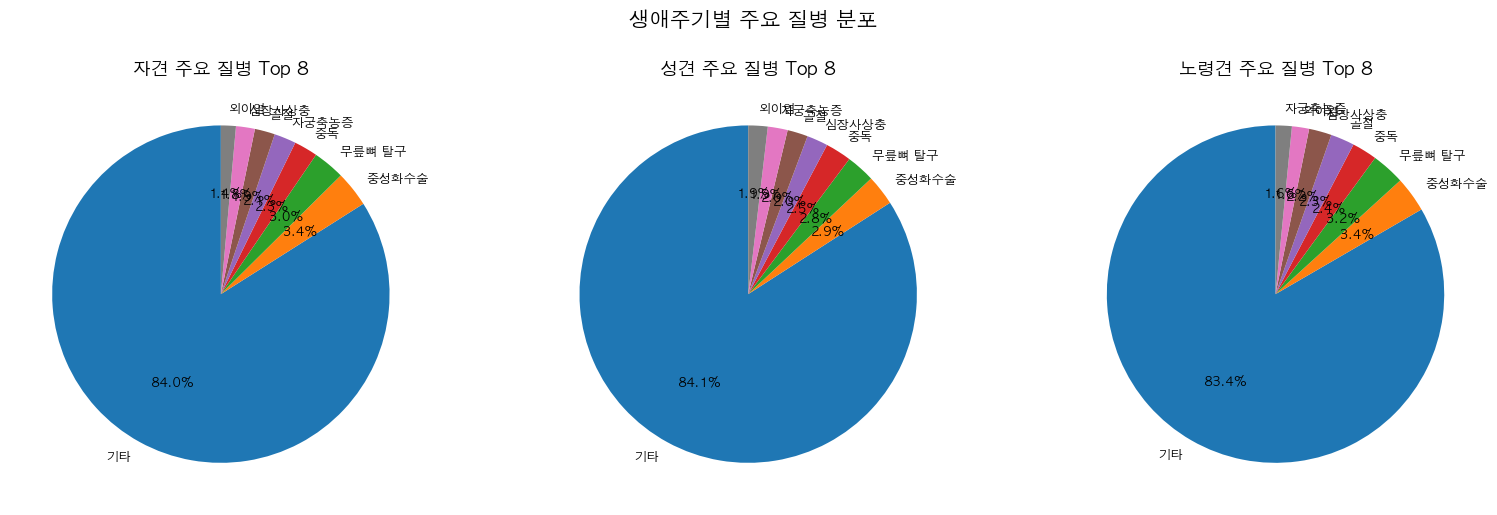

In [4]:
lifecycle_order = ['자견', '성견', '노령견']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, lc_name in zip(axes, lifecycle_order):
    subset = df[df['lifeCycle'] == lc_name]['disease'].value_counts().head(8)
    ax.pie(
        subset.values,
        labels=subset.index,
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 9}
    )
    ax.set_title(f'{lc_name} 주요 질병 Top 8', fontsize=13, fontweight='bold')

plt.suptitle('생애주기별 주요 질병 분포', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(EDA_OUTPUT / 'lifecycle_disease_pie.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. 생애주기 × 진료과 교차 분석 (히트맵)

In [5]:

# 상위 30개 질병만 표시 (가독성 확보)
top_diseases = df['disease'].value_counts().head(30).index
df_sunburst  = df[df['disease'].isin(top_diseases)].copy()

fig = px.sunburst(
    df_sunburst,
    path=['lifeCycle', 'department', 'disease'],
    title='생애주기 → 진료과 → 질병 계층 구조 (Top 30 질병)',
    color='lifeCycle',
    color_discrete_map={'자견': '#4C72B0', '성견': '#55A868', '노령견': '#DD8452'},
    width=700, height=700
)
fig.update_traces(textinfo='label+percent entry')
fig.write_html(str(EDA_OUTPUT / 'sunburst_hierarchy.html'))
fig.show()

## 4-1. 계층 구조 Sunburst (lifeCycle → department → disease)

파이차트로는 볼 수 없는 3단계 계층 관계를 한 화면에 표현.  
어떤 생애주기의 어떤 진료과에서 어떤 질병이 많은지 한눈에 파악 가능.

In [6]:
crosstab = pd.crosstab(df['lifeCycle'], df['department'])
crosstab = crosstab.reindex(lifecycle_order)  # 순서 고정

fig = px.imshow(
    crosstab,
    text_auto=True,
    color_continuous_scale='Blues',
    title='생애주기 × 진료과 교차 분석',
    labels=dict(x='진료과', y='생애주기', color='레코드 수')
)
fig.update_layout(font=dict(size=13))
fig.write_html(str(EDA_OUTPUT / 'lifecycle_dept_heatmap.html'))
fig.show()

## 5. 생애주기별 워드클라우드

In [ ]:
FONT_PATH = '/System/Library/Fonts/Supplemental/AppleGothic.ttf'

# 워드클라우드 전용 추가 불용어 — 형태소 어간 추출 후 나오는 고빈도 일반 동사
WC_STOPWORDS = {
    # 일반 동사 어간
    '하다', '있다', '되다', '이다', '않다', '없다', '같다', '보다',
    '줄다', '알다', '주다', '받다', '오다', '가다', '나다', '들다',
    '크다', '좋다', '많다', '싶다', '아니다', '그렇다', '드리다',
    # Q&A 템플릿 반복 문구
    '요점', '위주', '순서', '실행', '핵심', '간단하다', '설명',
    '부탁드리다', '정리', '주시', '또한', '다시', '별로', '이후',
    '증상', '나타나다', '경우', '병원', '방문', '격정', '걱정',
    # 대명사·지시어
    '저희', '이렇다', '그렇다', '저', '제', '때문',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, lc_name in zip(axes, lifecycle_order):
    tokens_raw = ' '.join(
        df[df['lifeCycle'] == lc_name]['input_tokens'].dropna()
    )
    # 불용어 필터링 후 재결합
    filtered = ' '.join(
        w for w in tokens_raw.split() if w not in WC_STOPWORDS
    )
    wc = WordCloud(
        font_path=FONT_PATH,
        width=600, height=400,
        background_color='white',
        max_words=60,
        colormap='Blues'
    ).generate(filtered)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{lc_name} 키워드', fontsize=13, fontweight='bold')

plt.suptitle('생애주기별 질문 키워드 워드클라우드', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_OUTPUT / 'wordcloud_lifecycle.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. 진료과별 Top 10 질병 (막대 그래프)

In [8]:

df['input_len']  = df['input_clean'].str.len()
df['output_len'] = df['output_clean'].str.len()

fig = px.box(
    df,
    x='lifeCycle',
    y='input_len',
    color='lifeCycle',
    category_orders={'lifeCycle': lifecycle_order},
    color_discrete_map={'자견': '#4C72B0', '성견': '#55A868', '노령견': '#DD8452'},
    title='생애주기별 질문 길이 분포 (Box Plot)',
    labels={'input_len': '질문 길이 (글자 수)', 'lifeCycle': '생애주기'},
    points='outliers'  # 이상치만 점으로 표시
)
fig.write_html(str(EDA_OUTPUT / 'boxplot_input_length.html'))
fig.show()

# 수치 요약
print("=== 생애주기별 질문 길이 통계 ===")
print(df.groupby('lifeCycle')['input_len'].describe().round(1).to_string())

=== 생애주기별 질문 길이 통계 ===
            count   mean    std   min    25%    50%    75%     max
lifeCycle                                                         
노령견        7169.0  329.8  253.6  25.0  164.0  258.0  419.0  3130.0
성견         7275.0  327.3  252.3  30.0  161.0  256.0  414.0  2697.0
자견         7160.0  331.3  258.1  32.0  160.8  259.0  421.0  3208.0


## 7-2. 생애주기별 Q&A 길이 Box Plot

히스토그램과 달리 생애주기 간 통계적 분포를 직접 비교 가능.  
노령견 질문이 더 길고 복잡한지, 자견 질문이 단순한지 확인.

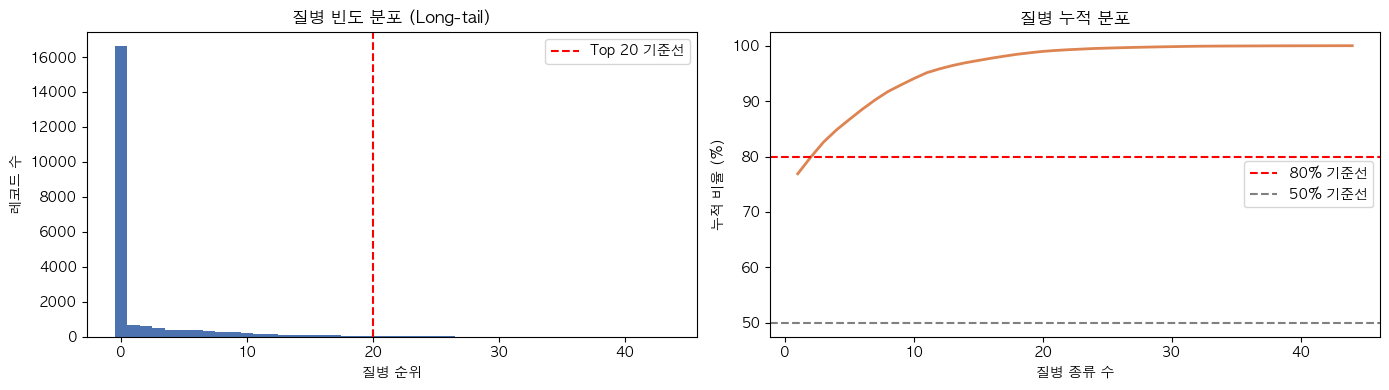

전체 질병 종류: 44개
상위 0개 질병 → 전체 데이터의 50% 차지
상위 2개 질병 → 전체 데이터의 80% 차지


In [9]:

disease_counts = df['disease'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# 전체 질병 빈도 (롱테일)
axes[0].bar(range(len(disease_counts)), disease_counts.values, color='#4C72B0', width=1.0)
axes[0].set_title('질병 빈도 분포 (Long-tail)')
axes[0].set_xlabel('질병 순위')
axes[0].set_ylabel('레코드 수')
axes[0].axvline(x=20, color='red', linestyle='--', label='Top 20 기준선')
axes[0].legend()

# 누적 분포 — 상위 N개 질병이 전체의 몇 %를 차지하는지
cumulative_pct = (disease_counts.cumsum() / disease_counts.sum() * 100)
axes[1].plot(range(1, len(cumulative_pct) + 1), cumulative_pct.values, color='#DD8452', linewidth=2)
axes[1].axhline(y=80, color='red', linestyle='--', label='80% 기준선')
axes[1].axhline(y=50, color='gray', linestyle='--', label='50% 기준선')
top_50pct = (cumulative_pct <= 50).sum()
top_80pct = (cumulative_pct <= 80).sum()
axes[1].set_title('질병 누적 분포')
axes[1].set_xlabel('질병 종류 수')
axes[1].set_ylabel('누적 비율 (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig(EDA_OUTPUT / 'disease_longtail.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"전체 질병 종류: {len(disease_counts)}개")
print(f"상위 {top_50pct}개 질병 → 전체 데이터의 50% 차지")
print(f"상위 {top_80pct}개 질병 → 전체 데이터의 80% 차지")

## 7-1. 질병 Long-tail 분포

데이터 마이닝에서 핵심 — 소수 질병에 데이터가 집중되어 있으면  
매칭 모델이 희소 질병에서 성능이 떨어질 수 있음.

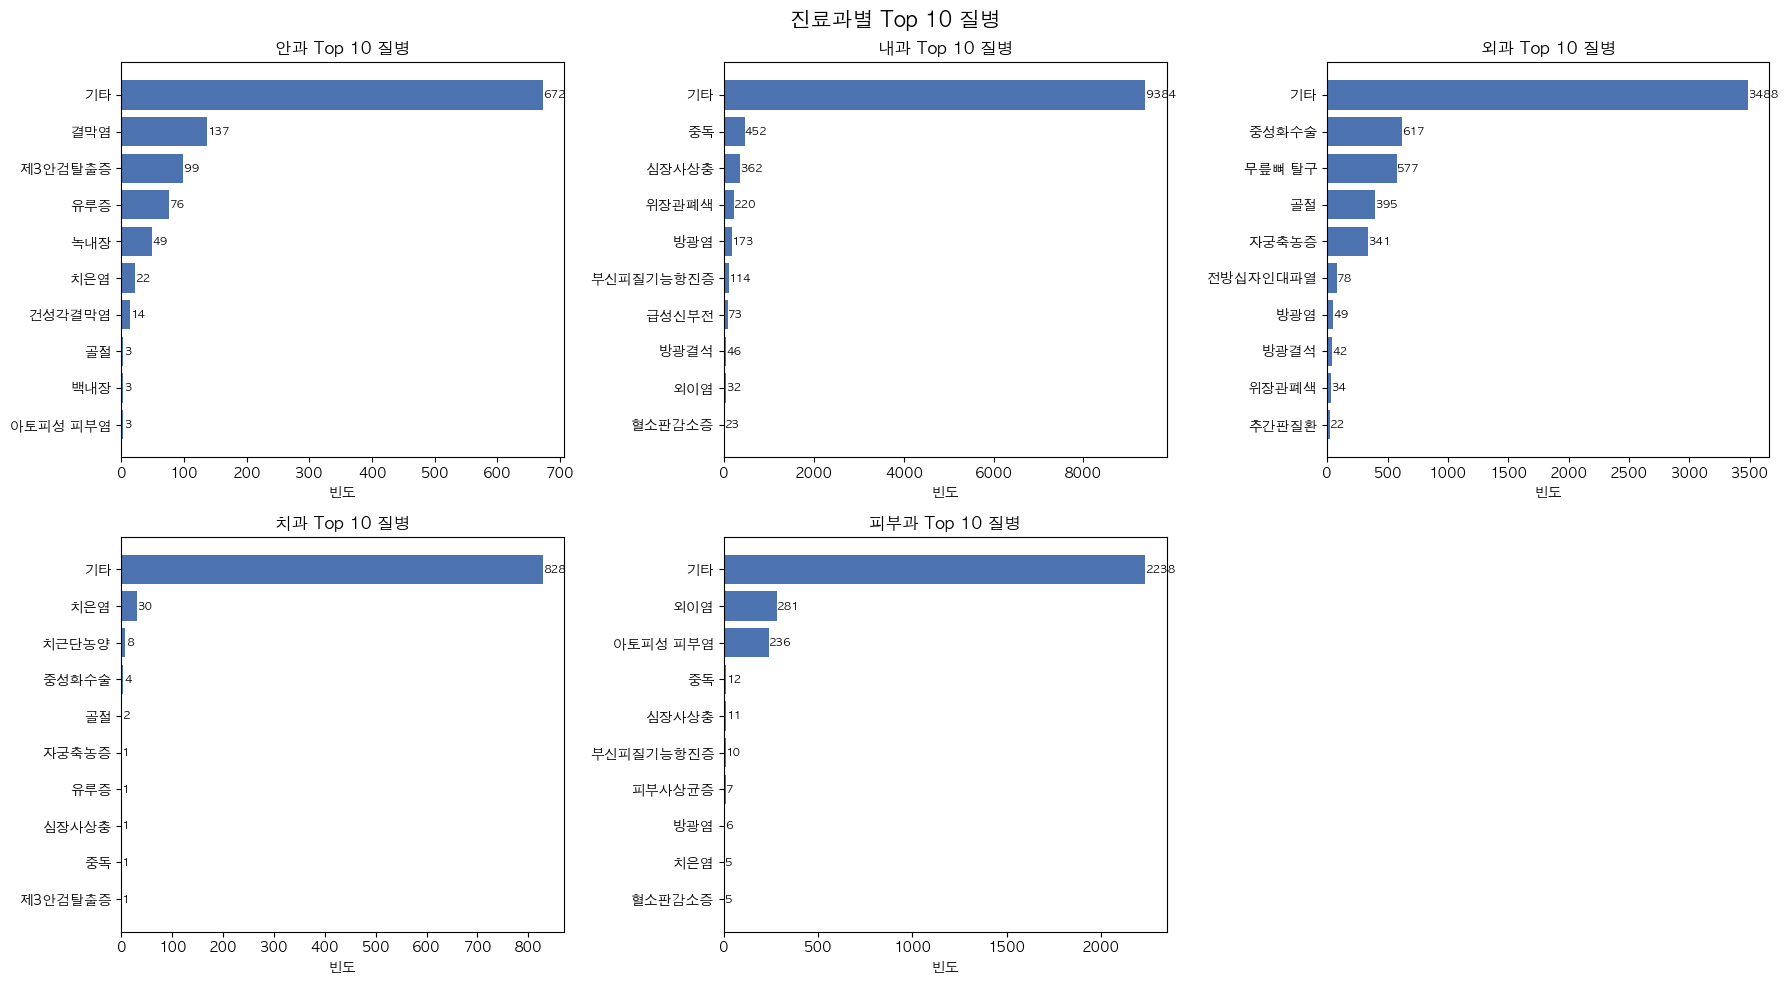

In [10]:
departments = df['department'].unique()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, dept_name in zip(axes, departments):
    top10 = df[df['department'] == dept_name]['disease'].value_counts().head(10)
    ax.barh(top10.index[::-1], top10.values[::-1], color='#4C72B0')
    ax.set_title(f'{dept_name} Top 10 질병', fontweight='bold')
    ax.set_xlabel('빈도')
    for i, v in enumerate(top10.values[::-1]):
        ax.text(v + 1, i, str(v), va='center', fontsize=8)

axes[-1].set_visible(False)  # 빈 subplot 숨김
plt.suptitle('진료과별 Top 10 질병', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(EDA_OUTPUT / 'dept_top10_disease.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Q&A 텍스트 길이 분포

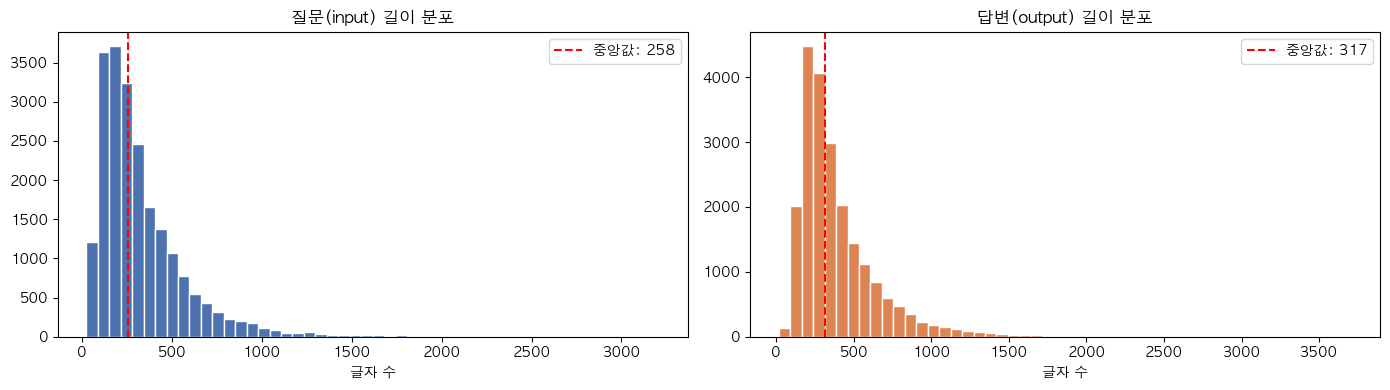

       input_len  output_len
count    21604.0     21604.0
mean       329.5       394.4
std        254.7       266.1
min         25.0        18.0
25%        162.0       219.0
50%        258.0       317.0
75%        418.0       485.0
max       3208.0      3707.0


In [11]:
df['input_len']  = df['input_clean'].str.len()
df['output_len'] = df['output_clean'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['input_len'],  bins=50, color='#4C72B0', edgecolor='white')
axes[0].set_title('질문(input) 길이 분포')
axes[0].set_xlabel('글자 수')
axes[0].axvline(df['input_len'].median(), color='red', linestyle='--', label=f'중앙값: {df["input_len"].median():.0f}')
axes[0].legend()

axes[1].hist(df['output_len'], bins=50, color='#DD8452', edgecolor='white')
axes[1].set_title('답변(output) 길이 분포')
axes[1].set_xlabel('글자 수')
axes[1].axvline(df['output_len'].median(), color='red', linestyle='--', label=f'중앙값: {df["output_len"].median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(EDA_OUTPUT / 'text_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

print(df[['input_len', 'output_len']].describe().round(1))

## 8. 중간 인사이트 (보고서 5번 항목)

In [12]:
print("=== 생애주기별 주요 질병 Top 3 ===")
for lc_name in lifecycle_order:
    top3 = df[df['lifeCycle'] == lc_name]['disease'].value_counts().head(3)
    print(f"\n[{lc_name}]")
    for disease, count in top3.items():
        print(f"  {disease}: {count:,}건")

=== 생애주기별 주요 질병 Top 3 ===

[자견]
  기타: 5,521건
  중성화수술: 225건
  무릎뼈 탈구: 200건

[성견]
  기타: 5,616건
  중성화수술: 194건
  무릎뼈 탈구: 184건

[노령견]
  기타: 5,474건
  중성화수술: 223건
  무릎뼈 탈구: 209건


## 9. EDA 요약

| 항목 | 결과 |
|------|------|
| 전체 레코드 | (실행 후 기입) |
| 고유 질병 수 | (실행 후 기입) |
| 자견 주요 질병 | (실행 후 기입) |
| 성견 주요 질병 | (실행 후 기입) |
| 노령견 주요 질병 | (실행 후 기입) |
| 생성된 시각화 | lifecycle_disease_pie.png, wordcloud_lifecycle.png, dept_top10_disease.png, lifecycle_dept_heatmap.html |

### 중간 인사이트
- (실행 후 발견된 패턴 기입)
- (예: 노령견에서 종양 관련 질병 빈도가 높음)
- (예: 피부과 질환은 성견에 집중)

> **다음 단계**: `05_ground_truth.ipynb` — 평가셋 수동 구축 (MRR/Top-K 측정 기준)